# Comparison of Local Context Correlations: All Documents vs. Citable Documents

This notebook performs a systematic comparison between the correlations calculated for **All Documents** and **Citable Documents** in the Local Context across different ESI (Essential Science Indicators) fields.



In [3]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
%cd "/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Local Context/"
!ls

/content/gdrive/.shortcut-targets-by-id/0B5aSrRJgnViLfm9LWl9TY21TWm5wSU0zbkgzc2YyeEp3RzJMaEJOR2FWbFkxVEZYTjNQd1E/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Local Context
ai.txt				 pearson_correlation_AI_FMeasure.csv
AMEASURE.txt			 rsi.txt
figuras				 scatterplots
FMEASURE.txt			 scatterplots.html
GAggregation.txt		 share.txt
GMEASURE.txt			 Spearman_correlation_AI_FMeasure.csv
manuscriptFiguresAndTables.html  Wshare.txt


In [5]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.titlesize': 14,
    'figure.titleweight': 'bold'
})


# Initialize HTML report container
text = """
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Comparison Analysis Report</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; color: #2c3e50; }
        h1, h2, h3 { color: #2c3e50; }
        table { border-collapse: collapse; width: 100%; margin-bottom: 20px; }
        th, td { border: 1px solid #bdc3c7; padding: 8px; text-align: left; }
        th { background-color: #f4f6f7; font-weight: bold; }
        img { max-width: 100%; height: auto; display: block; margin: 20px 0; }
    </style>
</head>
<body>
<h1>Comparison Analysis Report (All vs. Citable Documents)</h1>
"""


In [7]:
# Define paths to the CSV files
paths = {
    'all_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Local Context/pearson_correlation_AI_FMeasure.csv',
    'all_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Local Context/Spearman_correlation_AI_FMeasure.csv',
    'citable_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/InCites/Local Context/pearson_correlation_AI_FMeasure.csv',
    'citable_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/InCites/Local Context/Spearman_correlation_AI_FMeasure.csv'
}

# Load files
dfs = {}
for name, path in paths.items():
    if not os.path.exists(path):
        # Try relative paths as fallback
        if '2026' in path:
            rel_path = f'Global Context/{os.path.basename(path)}'
        else:
            rel_path = f'../../ManuscriptExperiments/Global Context/{os.path.basename(path)}'
        if os.path.exists(rel_path):
            path = rel_path

    dfs[name] = pd.read_csv(path, index_col=0)
    print(f"Successfully loaded {name} (Shape: {dfs[name].shape})")


Successfully loaded all_pearson (Shape: (221, 11))
Successfully loaded all_spearman (Shape: (221, 10))
Successfully loaded citable_pearson (Shape: (219, 11))
Successfully loaded citable_spearman (Shape: (219, 10))


In [19]:
def get_comparison_table(col_name):
    """
    Creates a side-by-side comparison table for a specific correlation column.
    """
    # Base index of ESI fields from the Pearson All dataset
    index_ref = dfs['all_pearson'].index

    df_comp = pd.DataFrame(index=index_ref)

    # Pearson
    df_comp['Pearson (All)'] = dfs['all_pearson'][col_name]
    df_comp['Pearson (Citable)'] = dfs['citable_pearson'][col_name]
    df_comp['Pearson Diff (Citable - All)'] = df_comp['Pearson (Citable)'] - df_comp['Pearson (All)']

    # Spearman (aligning indices)
    df_comp['Spearman (All)'] = df_comp.index.map(dfs['all_spearman'][col_name])
    df_comp['Spearman (Citable)'] = df_comp.index.map(dfs['citable_spearman'][col_name])
    df_comp['Spearman Diff (Citable - All)'] = df_comp['Spearman (Citable)'] - df_comp['Spearman (All)']

    # Sort ESI Fields alphabetically
    df_comp = df_comp.sort_index()
    return df_comp

def display_styled_table(df, title):
    """
    Applies advanced pandas styler to color-code difference columns and display.
    """
    styled = df.style.format("{:.4f}")\
        .background_gradient(cmap="coolwarm", subset=["Pearson Diff (Citable - All)", "Spearman Diff (Citable - All)"], vmin=-0.2, vmax=0.2)\
        .set_caption(f"<b style='font-size: 14px;'>{title}</b>")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'right')]},
            {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
        ])
    display(styled)
    global text
    text = text + f"<h2>{title}</h2>" + styled.to_html() + "<br><br>"

def plot_comparison(df, user_name):
    """
    Generates side-by-side horizontal bar plots to visualize the differences in correlations.
    """
    # Prepare Pearson data for Seaborn
    df_pearson = pd.DataFrame({
        'ESI Field': df.index,
        'All Documents': df['Pearson (All)'].values,
        'Citable Documents': df['Pearson (Citable)'].values
    }).melt(id_vars='ESI Field', var_name='Dataset', value_name='Pearson Correlation')

    # Prepare Spearman data for Seaborn
    df_spearman = pd.DataFrame({
        'ESI Field': df.index,
        'All Documents': df['Spearman (All)'].values,
        'Citable Documents': df['Spearman (Citable)'].values
    }).melt(id_vars='ESI Field', var_name='Dataset', value_name='Spearman Correlation')

    fig, axes = plt.subplots(1, 2, figsize=(16, 49), sharey=True)

    # Harmonious colors: Cool Blue for All, Warm Coral for Citable
    colors = {'All Documents': '#2b7bba', 'Citable Documents': '#e76f51'}

    # Pearson Subplot
    sns.barplot(
        data=df_pearson,
        y='ESI Field',
        x='Pearson Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[0]
    )
    axes[0].set_title("Pearson Correlation Coefficient", fontsize=13, pad=10)
    axes[0].set_xlabel("Correlation Value")
    axes[0].set_ylabel("ESI Field")
    axes[0].set_xlim(-1.05, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[0].legend().set_visible(False)

    # Spearman Subplot
    sns.barplot(
        data=df_spearman,
        y='ESI Field',
        x='Spearman Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[1]
    )
    axes[1].set_title("Spearman Correlation Coefficient", fontsize=13, pad=10)
    axes[1].set_xlabel("Correlation Value")
    axes[1].set_ylabel("")
    axes[1].set_xlim(-1.05, 1.05)
    axes[1].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[1].legend().set_visible(False)

    # Add single common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=11)

    plt.suptitle(f"Correlation Comparison: {user_name} (All vs. Citable)", fontsize=15, y=1.03)
    plt.tight_layout()
    import os
    os.makedirs('figuras', exist_ok=True)
    fig_name_clean = user_name.replace(' ', '_').replace('/', '_').replace(':', '_').replace('(', '').replace(')', '')
    fig_filename = f"figuras/comparison_{fig_name_clean}.png"
    plt.savefig(fig_filename, bbox_inches='tight')
    global text
    text = text + f"<img src='{fig_filename}' alt='{user_name} Comparison'><br><br>\n"
    plt.show()


## 1. AI vs DShareC Correlation Comparison

This section compares the Pearson and Spearman correlations of **Activity Index (AI)** versus **DShareC**.
This indicator measures how the proportion of publications (AI) relates to the document share in the citation distribution.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
FRENCH POLYNESIA,1.0000,nan,nan,1.0000,nan,nan
NAURU,1.0000,nan,nan,1.0000,nan,nan
SERBIA & MONTENEGRO,0.5802,nan,nan,0.9955,nan,nan
MICRONESIA,0.6869,-0.2541,-0.9411,0.9897,0.3162,-0.6734
SAINT LUCIA,0.6212,-0.0483,-0.6695,0.9883,0.2582,-0.7301
PALAU,0.8662,0.7159,-0.1503,0.9883,0.7298,-0.2585
COOK ISLANDS,0.7705,-0.2609,-1.0314,0.9771,0.0000,-0.9771
TUVALU,0.8687,nan,nan,0.9762,nan,nan
SEYCHELLES,0.9860,0.9819,-0.0041,0.9734,0.8513,-0.1221
VATICAN,0.9454,0.9757,0.0302,0.9677,0.7486,-0.2191


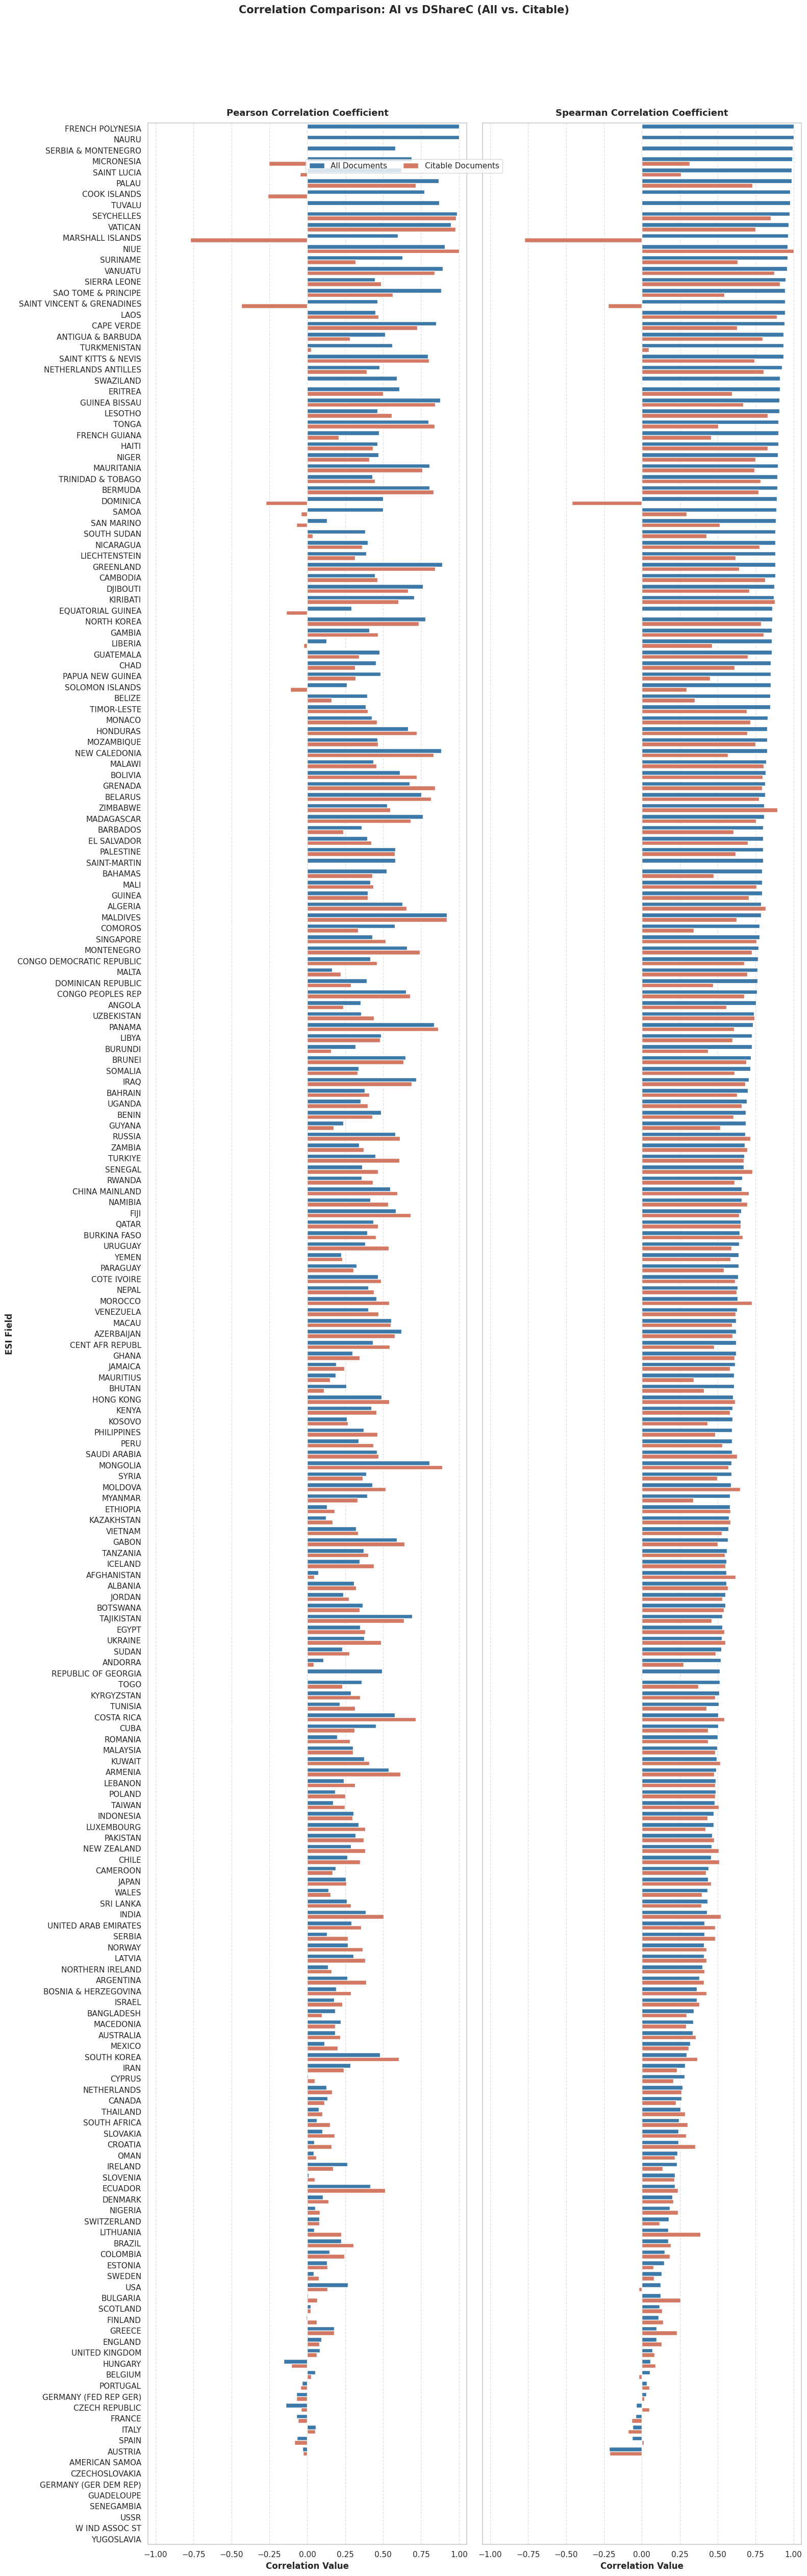

In [20]:
df_ai_dsharec = get_comparison_table('AI vs DShareC')
display_styled_table(df_ai_dsharec.sort_values('Spearman (All)', ascending=False), 'Table 1: AI vs DShareC (All vs. Citable)')
plot_comparison(df_ai_dsharec.sort_values('Spearman (All)', ascending=False), 'AI vs DShareC')


## 2. AI vs CShareD Correlation Comparison

This section compares the correlations of **Activity Index (AI)** versus **CShareD**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
AFGHANISTAN,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
ALBANIA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
ALGERIA,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
ANDORRA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
ANGOLA,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
ANTIGUA & BARBUDA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
ARGENTINA,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
ARMENIA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AUSTRALIA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AUSTRIA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000


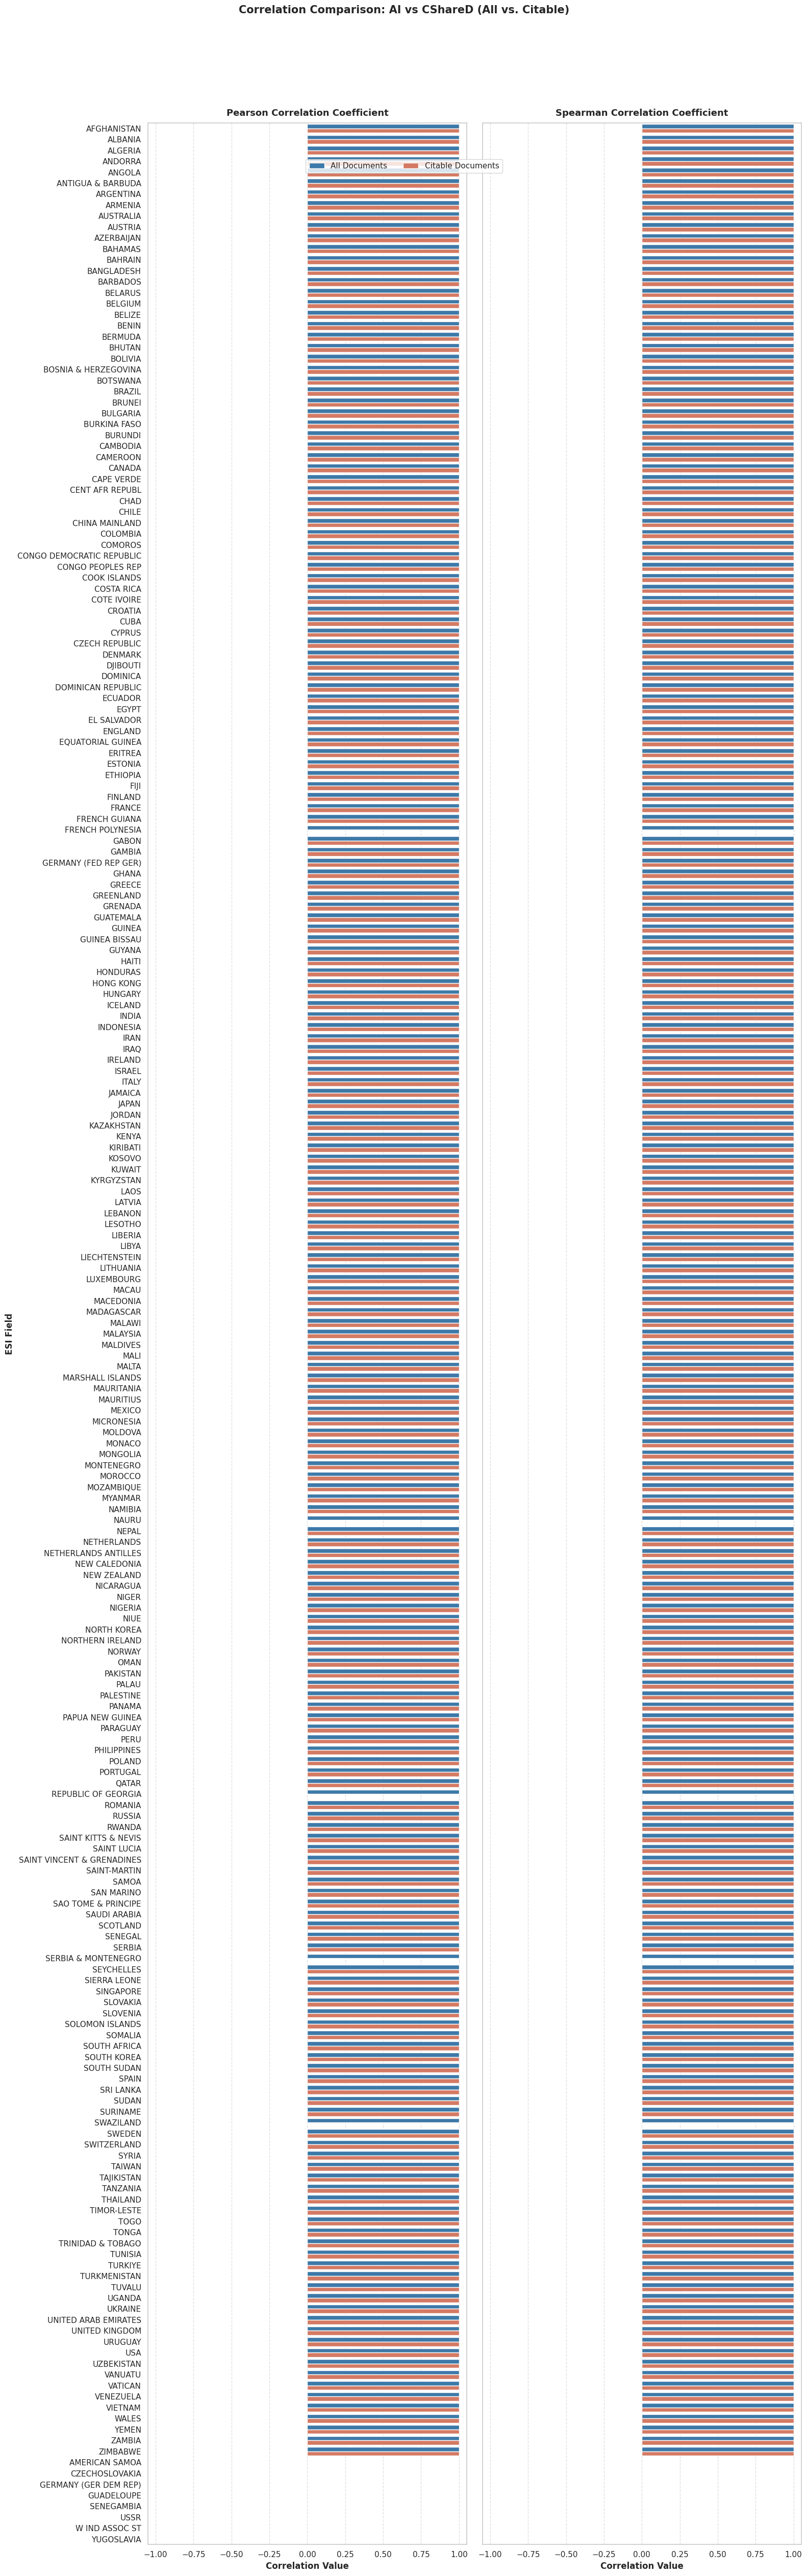

In [21]:
df_ai_cshared = get_comparison_table('AI vs CShareD')
display_styled_table(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'Table 2: AI vs CShareD (All vs. Citable)')
plot_comparison(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'AI vs CShareD')


## 3. F-Measure vs DShareC (ShareC) Correlation Comparison

This section compares the correlations of **F-Measure** versus **DShareC**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
FRENCH POLYNESIA,1.0000,nan,nan,1.0000,nan,nan
NAURU,1.0000,nan,nan,1.0000,nan,nan
CHINA MAINLAND,0.9867,0.9944,0.0077,0.9955,0.9989,0.0034
SERBIA & MONTENEGRO,0.5802,nan,nan,0.9955,nan,nan
USA,0.9855,0.9812,-0.0043,0.9898,0.9831,-0.0068
MICRONESIA,0.6870,-0.2541,-0.9410,0.9897,0.3162,-0.6734
SAINT LUCIA,0.6212,-0.0482,-0.6694,0.9883,0.2582,-0.7301
PALAU,0.8662,0.7160,-0.1502,0.9883,0.7298,-0.2585
COOK ISLANDS,0.7705,-0.2608,-1.0314,0.9771,0.0000,-0.9771
TUVALU,0.8687,nan,nan,0.9762,nan,nan


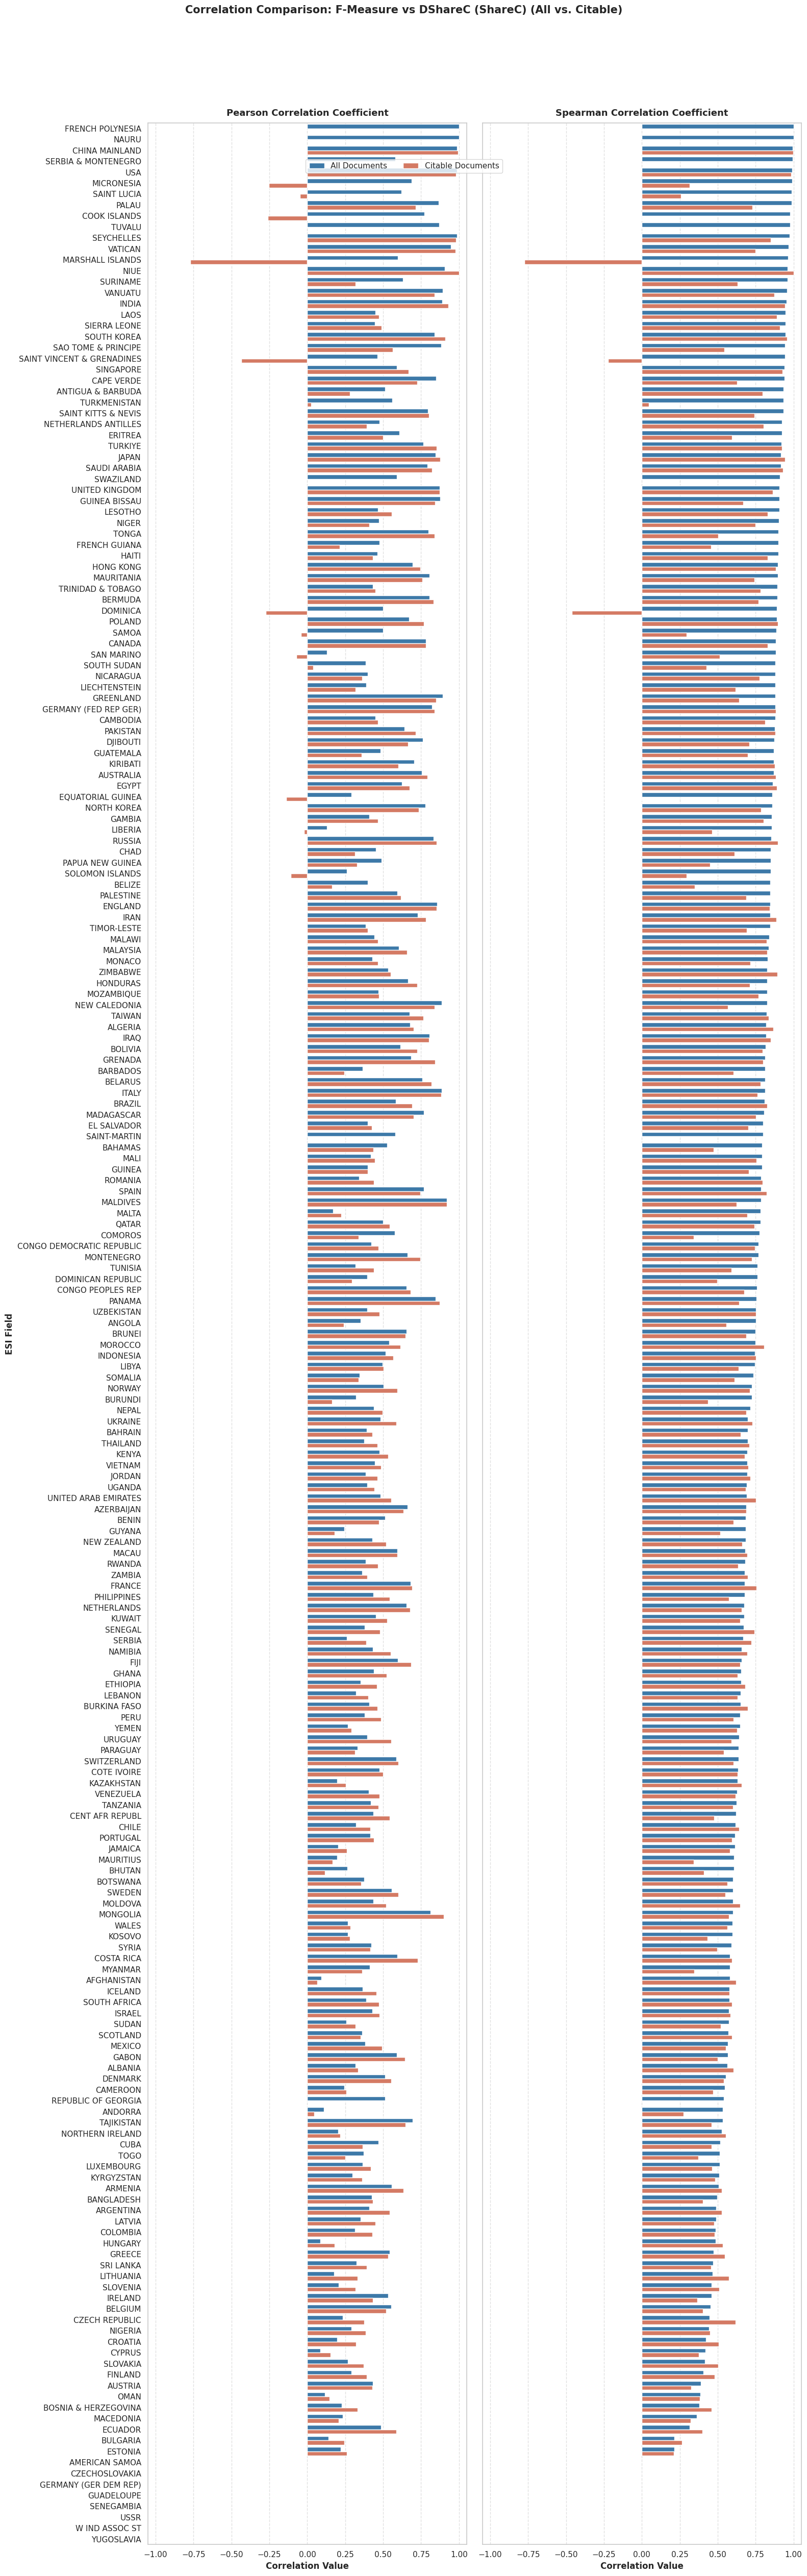

In [22]:
df_f_dsharec = get_comparison_table('F-Measure vs DShareC')
display_styled_table(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'Table 3: F-Measure vs DShareC (All vs. Citable)')
plot_comparison(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'F-Measure vs DShareC (ShareC)')


## 4. F-Measure vs CShareD Correlation Comparison

This section compares the correlations of **F-Measure** versus **CShareD**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
ANGOLA,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
BHUTAN,0.9999,0.9999,-0.0000,1.0000,1.0000,0.0000
BERMUDA,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
BAHAMAS,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
ANTIGUA & BARBUDA,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
BELIZE,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
BENIN,0.9985,0.9970,-0.0014,1.0000,1.0000,0.0000
BELARUS,0.9999,1.0000,0.0000,1.0000,0.9987,-0.0013
COTE IVOIRE,0.9997,0.9994,-0.0003,1.0000,0.9989,-0.0011
DOMINICAN REPUBLIC,1.0000,0.9996,-0.0004,1.0000,0.9987,-0.0013


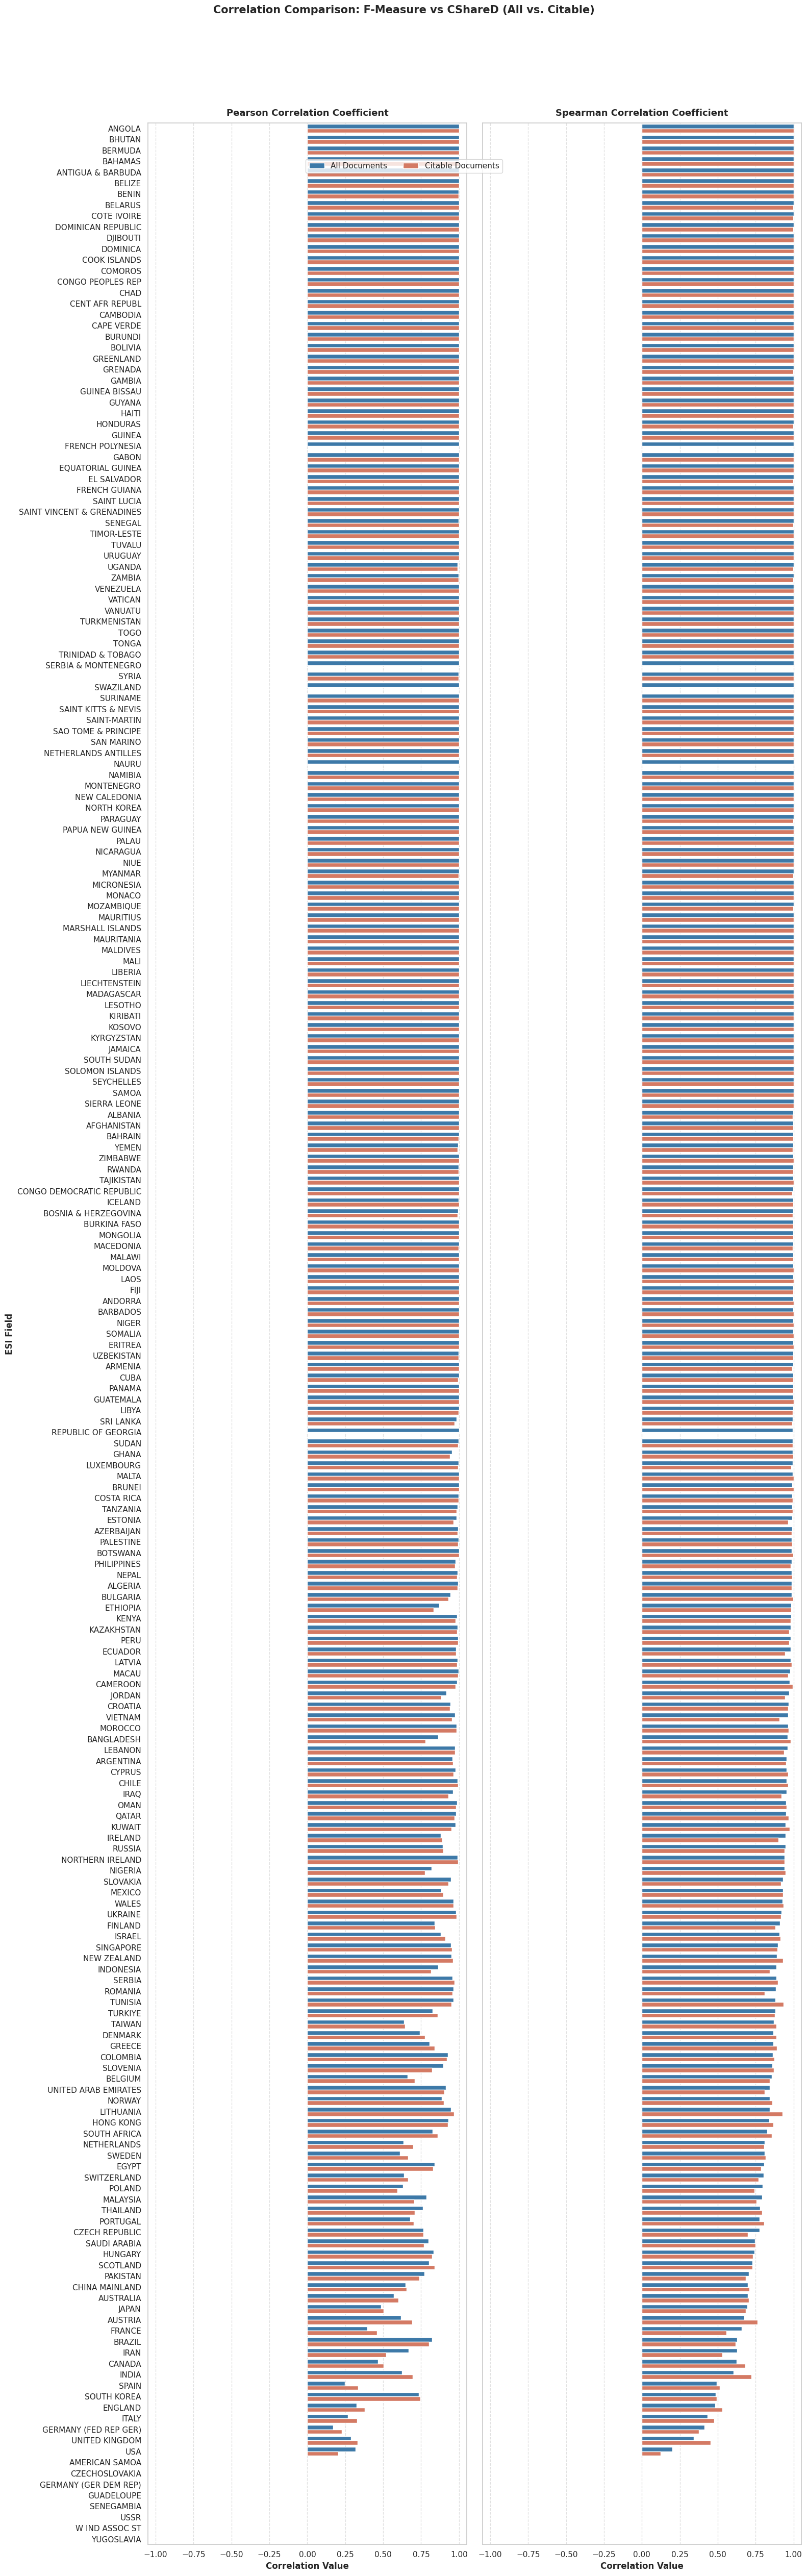

In [23]:
df_f_cshared = get_comparison_table('F-Measure vs CShareD')
display_styled_table(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'Table 4: F-Measure vs CShareD (All vs. Citable)')
plot_comparison(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'F-Measure vs CShareD')


## 5. Summary Statistics and Overall Analysis (Absolute Discrepancies)

To synthesize the comparison, let's look at the summary statistics of the **absolute differences** across all 22 ESI fields for each of the four indicator pairs.

Using absolute values is essential because it measures the magnitude of the discrepancy (change) regardless of whether the correlation went up or down. For example, a large negative change like -0.76708 represents a major discrepancy of 0.76708 in absolute terms. Computing statistics on signed differences can cause positive and negative changes to cancel each other out, hiding the true extent of the changes.


In [24]:
summary_data = []
pairs_mapping = {
    'AI vs DShareC': 'AI vs DShareC',
    'AI vs CShareD': 'AI vs CShareD',
    'F-Measure vs DShareC': 'F-Measure vs DShareC',
    'F-Measure vs CShareD': 'F-Measure vs CShareD'
}

for user_name, csv_name in pairs_mapping.items():
    df_p = get_comparison_table(csv_name)
    pearson_abs = df_p['Pearson Diff (Citable - All)'].abs()
    spearman_abs = df_p['Spearman Diff (Citable - All)'].abs()
    summary_data.append({
        'Indicator Pair': user_name,
        'Mean Abs Pearson Diff': pearson_abs.mean(),
        'Median Abs Pearson Diff': pearson_abs.median(),
        'Max Abs Pearson Diff': pearson_abs.max(),
        'Min Abs Pearson Diff': pearson_abs.min(),
        'Mean Abs Spearman Diff': spearman_abs.mean(),
        'Median Abs Spearman Diff': spearman_abs.median(),
        'Max Abs Spearman Diff': spearman_abs.max(),
        'Min Abs Spearman Diff': spearman_abs.min()
    })

df_summary = pd.DataFrame(summary_data).set_index('Indicator Pair')

styled_summary = df_summary.style.format("{:.5f}")\
    .background_gradient(cmap="Reds", vmin=0.0, vmax=0.3)\
    .set_caption("<b style='font-size: 14px;'>Overall Comparison Summary: Absolute Discrepancies (|Citable - All|)</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
        {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
    ])
display(styled_summary)
global text
text = text + "<h2>Overall Comparison Summary</h2>" + styled_summary.to_html() + "<br><br>"


,Mean Abs Pearson Diff,Median Abs Pearson Diff,Max Abs Pearson Diff,Min Abs Pearson Diff,Mean Abs Spearman Diff,Median Abs Spearman Diff,Max Abs Spearman Diff,Min Abs Spearman Diff
Indicator Pair,,,,,,,,
AI vs DShareC,0.10108,0.05505,1.36771,0.00020,0.13549,0.05903,1.73889,0.00095
AI vs CShareD,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
F-Measure vs DShareC,0.10366,0.06105,1.36774,0.00022,0.13243,0.05230,1.73889,0.00050
F-Measure vs CShareD,0.01117,0.00053,0.14631,0.00000,0.01110,0.00132,0.11745,0.00000


In [ ]:
global text
text = text + "</body></html>"
with open("manuscriptFiguresAndTables.html", "w", encoding="utf-8") as f:
    f.write(text)
print("Saved report to manuscriptFiguresAndTables.html")
